# Baseline Models
**Baseline A**: Sentiment Word Counting (rule-based)  
**Baseline B**: TF-IDF + Logistic Regression  

**Task**: 3-class sentiment classification  
`0 = negative | 1 = positive | 2 = neutral`

## 1. Imports

In [8]:
import pandas as pd
import numpy as np
import re
import time

import nltk
nltk.download('opinion_lexicon', quiet=True)
from nltk.corpus import opinion_lexicon

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)
import matplotlib.pyplot as plt

## 2. Load Data

In [9]:
df = pd.read_csv('merged_sentiment_clean.csv', encoding='utf-8-sig')
print(f'Total rows: {len(df)}')
print(df['label'].value_counts().sort_index().rename({0:'negative', 1:'positive', 2:'neutral'}))
df.head()

Total rows: 2577703
label
negative    1115465
positive     895845
neutral      566393
Name: count, dtype: int64


,id,text,label
0,0,i live with a big wonderful family that wants ...,1
1,1,i feel lucky like a four leaf clover a class p...,1
2,2,Ho la sensazione che saro' spezzato dal cuore ...,0
3,3,"Abbastanza divertente, ci sono cinque ragazzi....",2
4,4,Ich werde mich gut fühlen,1


## 3. Text Preprocessing

In [10]:
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)   # remove URLs
    text = re.sub(r'@\w+', '', text)              # remove mentions
    text = re.sub(r'#', '', text)                 # remove hashtag symbol
    text = re.sub(r'[^a-z\s]', ' ', text)        # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(preprocess)
df = df[df['clean_text'].str.len() > 0].reset_index(drop=True)
print(f'Rows after cleaning: {len(df)}')
df[['text', 'clean_text', 'label']].head()

Rows after cleaning: 2577503


,text,clean_text,label
0,i live with a big wonderful family that wants ...,i live with a big wonderful family that wants ...,1
1,i feel lucky like a four leaf clover a class p...,i feel lucky like a four leaf clover a class p...,1
2,Ho la sensazione che saro' spezzato dal cuore ...,ho la sensazione che saro spezzato dal cuore q...,0
3,"Abbastanza divertente, ci sono cinque ragazzi....",abbastanza divertente ci sono cinque ragazzi n...,2
4,Ich werde mich gut fühlen,ich werde mich gut f hlen,1


## 4. Train / Test Split

In [11]:
X_raw   = df['text']          # original text -- used by Baseline A
X_clean = df['clean_text']     # cleaned text  -- used by Baseline B
y       = df['label']

idx_train, idx_test = train_test_split(
    df.index, test_size=0.2, random_state=42, stratify=y
)

X_raw_train,   X_raw_test   = X_raw[idx_train],   X_raw[idx_test]
X_clean_train, X_clean_test = X_clean[idx_train], X_clean[idx_test]
y_train,       y_test       = y[idx_train],       y[idx_test]

print(f'Train: {len(y_train)}  |  Test: {len(y_test)}')

Train: 2062002  |  Test: 515501


---
## Baseline A: Sentiment Word Counting
Rule-based model using the **Opinion Lexicon** (Bing Liu).  
- positive words > negative words -> **positive (1)**  
- negative words > positive words -> **negative (0)**  
- tie or no sentiment words -> **neutral (2)**

In [12]:
POS_WORDS = set(opinion_lexicon.positive())
NEG_WORDS = set(opinion_lexicon.negative())
print(f'Positive words in lexicon: {len(POS_WORDS)}')
print(f'Negative words in lexicon: {len(NEG_WORDS)}')

Positive words in lexicon: 2006
Negative words in lexicon: 4783


In [13]:
def predict_word_count(text):
    tokens = str(text).lower().split()
    pos = sum(1 for t in tokens if t in POS_WORDS)
    neg = sum(1 for t in tokens if t in NEG_WORDS)
    if pos > neg:
        return 1   # positive
    elif neg > pos:
        return 0   # negative
    else:
        return 2   # neutral

# Use original text so punctuation does not strip lexicon matches
y_pred_a = X_raw_test.apply(predict_word_count)
print('Prediction distribution:', y_pred_a.value_counts().sort_index().to_dict())

Prediction distribution: {0: 85748, 1: 54888, 2: 374865}


### Baseline A — Evaluation

In [14]:
print(f'Accuracy: {accuracy_score(y_test, y_pred_a):.4f}')
print()
print(classification_report(
    y_test, y_pred_a,
    target_names=['negative', 'positive', 'neutral']
))

Accuracy: 0.3535

              precision    recall  f1-score   support

    negative       0.63      0.24      0.35    223092
    positive       0.65      0.20      0.30    179169
     neutral       0.25      0.82      0.38    113240

    accuracy                           0.35    515501
   macro avg       0.51      0.42      0.34    515501
weighted avg       0.55      0.35      0.34    515501



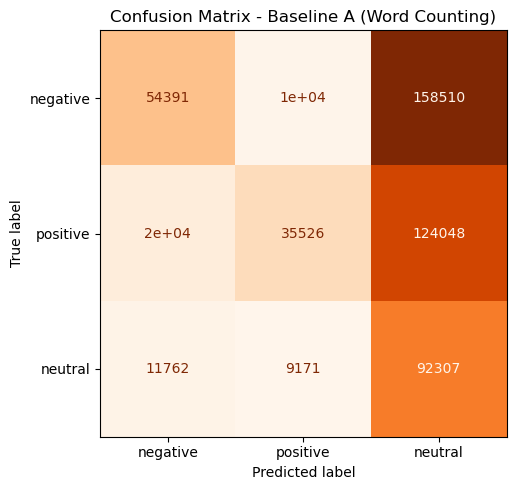

In [15]:
cm_a = confusion_matrix(y_test, y_pred_a)
disp_a = ConfusionMatrixDisplay(confusion_matrix=cm_a,
                                 display_labels=['negative', 'positive', 'neutral'])
fig, ax = plt.subplots(figsize=(6, 5))
disp_a.plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('Confusion Matrix - Baseline A (Word Counting)')
plt.tight_layout()
plt.savefig('baselineA_confusion_matrix.png', dpi=150)
plt.show()

---
## Baseline B: TF-IDF + Logistic Regression
Improvements over a plain unigram TF-IDF baseline:
- **Bigrams** (`ngram_range=(1,2)`) to capture phrases like *"not good"*
- **Sublinear TF scaling** to reduce dominance of high-frequency words
- **`min_df=3`** to filter out rare noise terms
- **`class_weight='balanced'`** to handle class imbalance
- **`solver='saga'`** supports `n_jobs=-1` for parallel training

In [16]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=80000,
    sublinear_tf=True,
    min_df=3,
    strip_accents='unicode'
)

X_train_vec = vectorizer.fit_transform(X_clean_train)
X_test_vec  = vectorizer.transform(X_clean_test)

print(f'Vocabulary size: {len(vectorizer.vocabulary_)}')
print(f'Train matrix shape: {X_train_vec.shape}')

Vocabulary size: 80000
Train matrix shape: (2062002, 80000)


In [17]:
t0 = time.time()

clf = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    solver='saga',
    multi_class='multinomial',
    random_state=42,
    n_jobs=-1
)
clf.fit(X_train_vec, y_train)

print(f'Training time: {time.time() - t0:.1f}s')

Training time: 48.2s


### Baseline B — Evaluation

In [18]:
y_pred_b = clf.predict(X_test_vec)

print(f'Accuracy: {accuracy_score(y_test, y_pred_b):.4f}')
print()
print(classification_report(
    y_test, y_pred_b,
    target_names=['negative', 'positive', 'neutral']
))

Accuracy: 0.8988

              precision    recall  f1-score   support

    negative       0.95      0.90      0.92    223092
    positive       0.91      0.88      0.90    179169
     neutral       0.80      0.93      0.86    113240

    accuracy                           0.90    515501
   macro avg       0.89      0.90      0.89    515501
weighted avg       0.90      0.90      0.90    515501



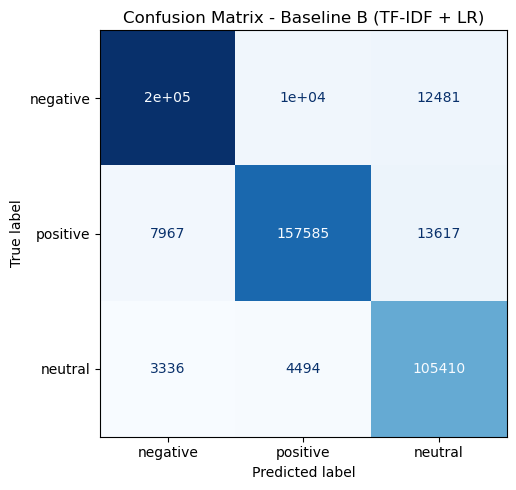

In [19]:
cm_b = confusion_matrix(y_test, y_pred_b)
disp_b = ConfusionMatrixDisplay(confusion_matrix=cm_b,
                                 display_labels=['negative', 'positive', 'neutral'])
fig, ax = plt.subplots(figsize=(6, 5))
disp_b.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix - Baseline B (TF-IDF + LR)')
plt.tight_layout()
plt.savefig('baselineB_confusion_matrix.png', dpi=150)
plt.show()

### Top Predictive Features per Class

In [20]:
feature_names = vectorizer.get_feature_names_out()
for i, cls in enumerate(['negative', 'positive', 'neutral']):
    top_idx = np.argsort(clf.coef_[i])[-15:][::-1]
    print(f'Top features [{cls}]:')
    print('  ', ', '.join(feature_names[top_idx]))
    print()

Top features [negative]:
   feel, sentimental, groggy, feeling, irritable, jaded, unzufrieden, unsicher, in til, courag, entmutigt, sento, beleidigt, grincheux, siento

Top features [positive]:
   feel, vital, intelligent, acceptable, sento, sociable, feeling, glamour, innocente, casual, innocent, sympathetic, vitale, intelligente, sincere

Top features [neutral]:
   schockiert, beeindruckt, choqu, impressionn, sorprendido, erstaunt, curioso, shocked, stupito, dazed, curieux, amazed, scioccato, berrascht, impressionato



### Quick Inference Test

In [21]:
label_map = {0: 'negative', 1: 'positive', 2: 'neutral'}

samples = [
    "I love this product, it's amazing!",
    "This is absolutely terrible, worst experience ever.",
    "The package arrived on Tuesday.",
    "Not bad, could be better.",
]

preds_a = [predict_word_count(s) for s in samples]
preds_b = clf.predict(vectorizer.transform([preprocess(s) for s in samples]))

header = f"{'Text':<47} {'Baseline A':>12} {'Baseline B':>12}"
print(header)
print('-' * len(header))
for text, pa, pb in zip(samples, preds_a, preds_b):
    print(f"{text:<47} {label_map[pa]:>12} {label_map[pb]:>12}")

Text                                              Baseline A   Baseline B
-------------------------------------------------------------------------
I love this product, it's amazing!                  positive     positive
This is absolutely terrible, worst experience ever.     negative     negative
The package arrived on Tuesday.                      neutral      neutral
Not bad, could be better.                            neutral      neutral


---
## Comparison: Baseline A vs Baseline B

In [22]:
results = pd.DataFrame({
    'Model': ['Baseline A (Word Count)', 'Baseline B (TF-IDF + LR)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_a),
        accuracy_score(y_test, y_pred_b)
    ],
    'Macro F1': [
        f1_score(y_test, y_pred_a, average='macro'),
        f1_score(y_test, y_pred_b, average='macro')
    ],
    'Weighted F1': [
        f1_score(y_test, y_pred_a, average='weighted'),
        f1_score(y_test, y_pred_b, average='weighted')
    ]
})

results = results.set_index('Model').round(4)
print(results.to_string())
results

                          Accuracy  Macro F1  Weighted F1
Model                                                    
Baseline A (Word Count)     0.3535    0.3447       0.3410
Baseline B (TF-IDF + LR)    0.8988    0.8932       0.8998


,Accuracy,Macro F1,Weighted F1
Model,,,
Baseline A (Word Count),0.3535,0.3447,0.3410
Baseline B (TF-IDF + LR),0.8988,0.8932,0.8998
